In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

from models.vqvae import VQVAE
from models.resnet import ResNet
from dataset.vae_dataset import VAEDataset

In [9]:
vqvae_checkpoint = 'weights/vqvae.ckpt'
resnet_checkpoint = 'weights/resnet.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data_path = 'train.memmap'

In [10]:
vqvae = VQVAE.load_from_checkpoint(vqvae_checkpoint, in_channels=5).to(device)
vqvae.eval()

resnet = ResNet(in_channels=8).to(device)

if device == "cuda":
    resnet.load_state_dict(torch.load(resnet_checkpoint, weights_only=True))
else:
    resnet.load_state_dict(torch.load(resnet_checkpoint, map_location=device, weights_only=True))

resnet.eval()

dataset = VAEDataset(data_path, channels=5, img_res=(128, 64))

In [11]:
sample = torch.Tensor(dataset[0]).unsqueeze(0).to(device)
real = torch.Tensor(dataset[1]).unsqueeze(0).to(device)

with torch.no_grad():
    _, latent, _ = vqvae(sample)

    pred = resnet(latent)
    pred, _, _ = vqvae.quantize(pred)

    _, latent_real, _ = vqvae(real)

    forecast = vqvae.decode(pred)

sample = sample.squeeze().cpu().numpy()
real = real.squeeze().cpu().numpy()

latent = latent.squeeze().cpu().numpy()
latent_real = latent_real.squeeze().cpu().numpy()
pred = pred.squeeze().cpu().numpy()

forecast = forecast.squeeze().cpu().numpy()

# mse between latent and pred
mse = np.mean((latent - pred) ** 2)
print(f'MSE between latent and pred: {mse}')


MSE between latent and pred: 0.03583330288529396


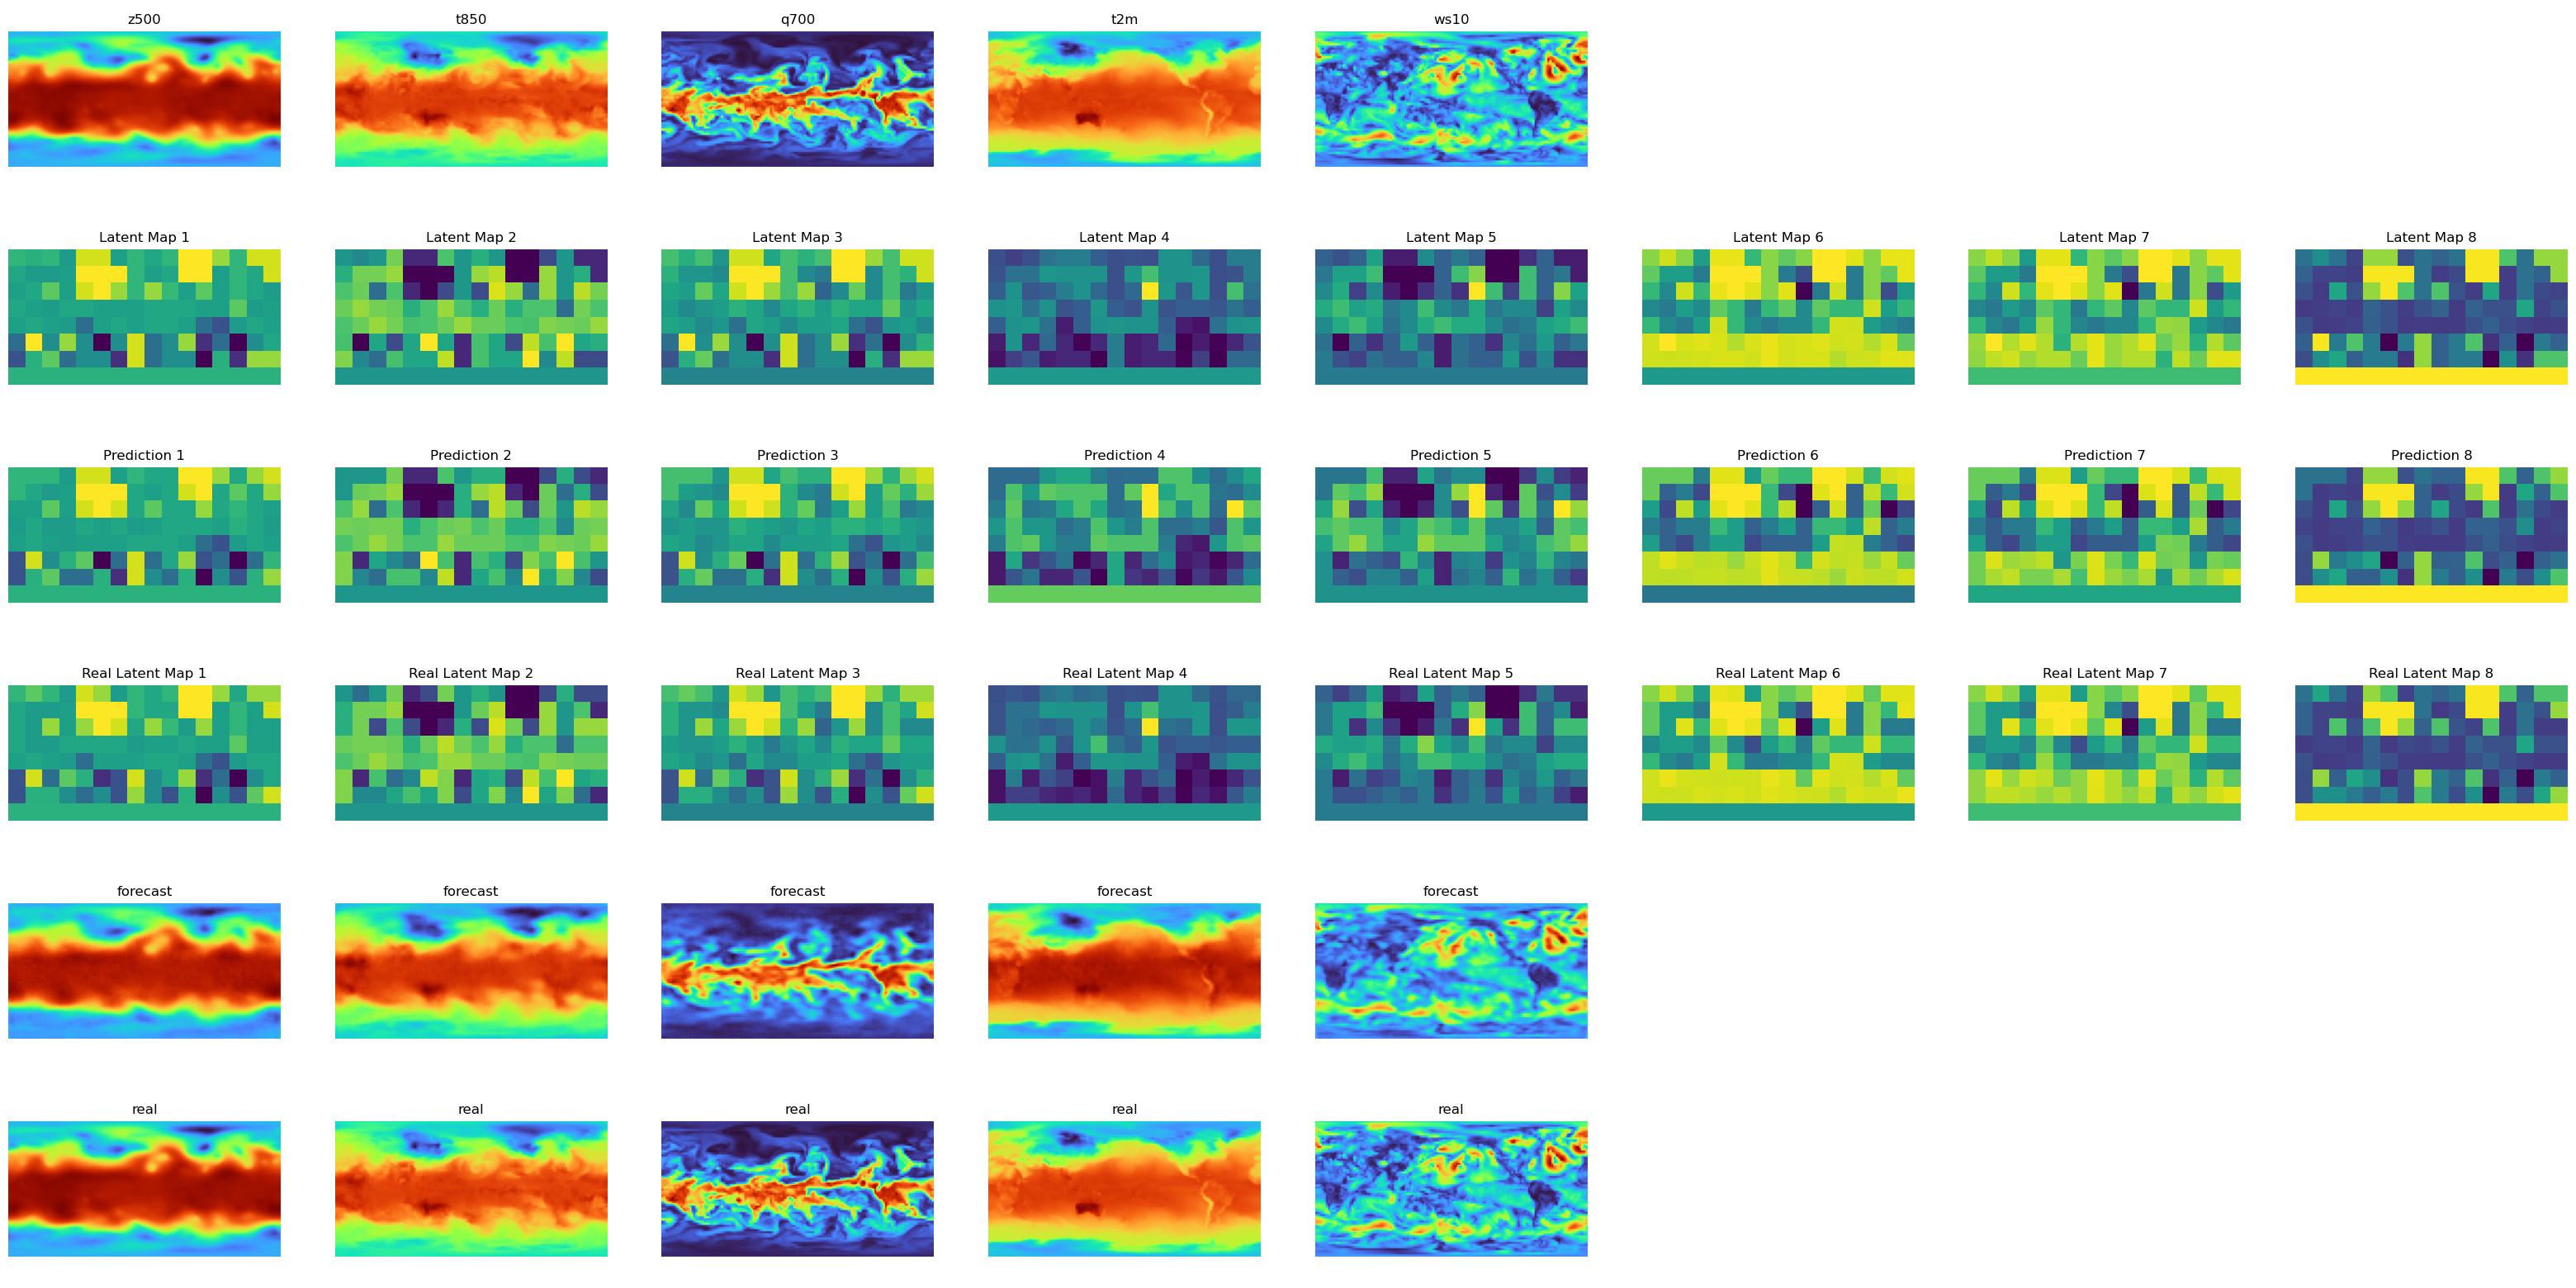

In [12]:
names = ['z500', 't850', 'q700', 't2m', 'ws10']

fig, axs = plt.subplots(6, 8, figsize=(40, 20))

for i in range(5):
    axs[0, i].imshow(real[i].T, cmap='turbo', origin='lower')
    axs[0, i].set_title(names[i])
    axs[0, i].axis('off')

for i in range(3):
    axs[0, i + 5].axis('off')

for i in range(8):
    axs[1, i].imshow(latent[i].T, origin='lower')
    axs[1, i].set_title('Latent Map ' + str(i + 1))
    axs[1, i].axis('off')

for i in range(8):
    axs[2, i].imshow(pred[i].T, origin='lower')
    axs[2, i].set_title('Prediction ' + str(i + 1))
    axs[2, i].axis('off')

for i in range(8):
    axs[3, i].imshow(latent_real[i].T, origin='lower')
    axs[3, i].set_title('Real Latent Map ' + str(i + 1))
    axs[3, i].axis('off')

for i in range(5):
    axs[4, i].imshow(forecast[i].T, cmap='turbo', origin='lower')
    axs[4, i].set_title('forecast')
    axs[4, i].axis('off')

for i in range(3):
    axs[4, i + 5].axis('off')

for i in range(5):
    axs[5, i].imshow(real[i].T, cmap='turbo', origin='lower')
    axs[5, i].set_title('real')
    axs[5, i].axis('off')

for i in range(3):
    axs[5, i + 5].axis('off')


plt.savefig('forecast.png')
plt.show()

